In [1]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, log_loss
from scipy.optimize import minimize

import lightgbm as lgb
import xgboost as xgb
import catboost as cb

import warnings
warnings.filterwarnings('ignore')

In [2]:
train_df = pl.read_csv('../data/train.csv')
test_df = pl.read_csv('../data/test.csv')

print('Train Data Shape:',{train_df.shape})
print('Test Data Shape:',{test_df.shape})

train_df.head()

Train Data Shape: {(630000, 21)}
Test Data Shape: {(270000, 20)}


id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
i64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,str,f64,str,f64,str,str
0,"""Loamy""",4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.9,16.79,"""Sugarcane""","""Sowing""","""Zaid""","""Drip""","""Rainwater""",0.82,"""No""",112.16,"""East""","""Low"""
1,"""Clay""",7.08,56.61,0.44,2.0,22.92,67.86,985.66,6.98,3.39,"""Wheat""","""Vegetative""","""Kharif""","""Rainfed""","""River""",5.27,"""Yes""",47.16,"""South""","""Low"""
2,"""Clay""",5.69,27.71,0.81,2.83,26.97,92.22,2201.7,6.05,3.85,"""Rice""","""Vegetative""","""Kharif""","""Sprinkler""","""Reservoir""",8.24,"""Yes""",110.38,"""North""","""Low"""
3,"""Sandy""",5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,2.31,"""Wheat""","""Flowering""","""Kharif""","""Canal""","""River""",8.32,"""Yes""",53.85,"""South""","""Medium"""
4,"""Clay""",7.96,59.14,0.38,0.96,20.22,91.11,1538.2,6.95,13.94,"""Wheat""","""Sowing""","""Rabi""","""Canal""","""River""",7.37,"""No""",93.19,"""South""","""Low"""


In [3]:
# Data Types and Null Values
print(train_df.schema)

# Null Values Check
print(train_df.null_count())

# Statistics
train_df.describe()

Schema([('id', Int64), ('Soil_Type', String), ('Soil_pH', Float64), ('Soil_Moisture', Float64), ('Organic_Carbon', Float64), ('Electrical_Conductivity', Float64), ('Temperature_C', Float64), ('Humidity', Float64), ('Rainfall_mm', Float64), ('Sunlight_Hours', Float64), ('Wind_Speed_kmh', Float64), ('Crop_Type', String), ('Crop_Growth_Stage', String), ('Season', String), ('Irrigation_Type', String), ('Water_Source', String), ('Field_Area_hectare', Float64), ('Mulching_Used', String), ('Previous_Irrigation_mm', Float64), ('Region', String), ('Irrigation_Need', String)])
shape: (1, 21)
┌─────┬───────────┬─────────┬──────────────┬───┬──────────────┬─────────────┬────────┬─────────────┐
│ id  ┆ Soil_Type ┆ Soil_pH ┆ Soil_Moistur ┆ … ┆ Mulching_Use ┆ Previous_Ir ┆ Region ┆ Irrigation_ │
│ --- ┆ ---       ┆ ---     ┆ e            ┆   ┆ d            ┆ rigation_mm ┆ ---    ┆ Need        │
│ u32 ┆ u32       ┆ u32     ┆ ---          ┆   ┆ ---          ┆ ---         ┆ u32    ┆ ---         │
│     ┆

statistic,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
str,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,str,f64,str,f64,str,str
"""count""",630000.0,"""630000""",630000.0,630000.0,630000.0,630000.0,630000.0,630000.0,630000.0,630000.0,630000.0,"""630000""","""630000""","""630000""","""630000""","""630000""",630000.0,"""630000""",630000.0,"""630000""","""630000"""
"""null_count""",0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""0""","""0""","""0""","""0""","""0""",0.0,"""0""",0.0,"""0""","""0"""
"""mean""",314999.5,null,6.482497,37.304482,0.922858,1.744605,26.998166,61.56318,1462.207566,7.513382,10.375394,null,null,null,null,null,7.517745,null,62.318177,null,null
"""std""",181865.479132,null,0.922504,16.377082,0.365808,0.952321,8.623621,19.708152,612.989738,1.999322,5.689458,null,null,null,null,null,4.218124,null,34.246939,null,null
"""min""",0.0,"""Clay""",4.8,8.0,0.3,0.1,12.0,25.0,0.38,4.0,0.5,"""Cotton""","""Flowering""","""Kharif""","""Canal""","""Groundwater""",0.3,"""No""",0.02,"""Central""","""High"""
"""25%""",157500.0,null,5.69,23.34,0.61,0.93,19.52,45.39,954.57,5.76,5.28,null,null,null,null,null,3.88,null,33.14,null,null
"""50%""",315000.0,null,6.44,37.75,0.91,1.74,26.96,61.65,1467.24,7.58,10.48,null,null,null,null,null,7.38,null,61.15,null,null
"""75%""",472499.0,null,7.27,51.27,1.22,2.58,34.54,79.12,2054.28,9.25,15.43,null,null,null,null,null,11.14,null,92.69,null,null
"""max""",629999.0,"""Silt""",8.2,64.99,1.6,3.5,42.0,94.99,2499.69,11.0,20.0,"""Wheat""","""Vegetative""","""Zaid""","""Sprinkler""","""River""",15.0,"""Yes""",119.99,"""West""","""Medium"""


# EDA

shape: (3, 3)
┌─────────────────┬────────┬───────┐
│ Irrigation_Need ┆ count  ┆ pct   │
│ ---             ┆ ---    ┆ ---   │
│ str             ┆ u32    ┆ f64   │
╞═════════════════╪════════╪═══════╡
│ Low             ┆ 369917 ┆ 58.72 │
│ Medium          ┆ 239074 ┆ 37.95 │
│ High            ┆ 21009  ┆ 3.33  │
└─────────────────┴────────┴───────┘


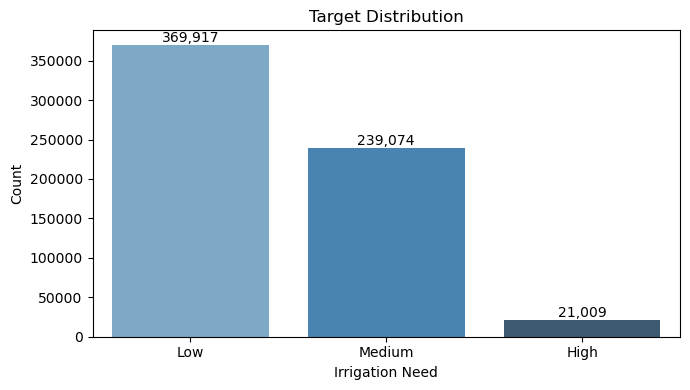

In [4]:
# Target Distribution
TARGET = 'Irrigation_Need'

target_counts = (
    train_df
    .group_by(TARGET)
    .agg(pl.len().alias('count'))
    .with_columns((pl.col('count') / pl.col('count').sum() * 100).round(2).alias('pct'))
    .sort('count', descending=True)
)
print(target_counts)

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(
    data=target_counts.to_pandas(),
    x=TARGET, y='count',
    order=target_counts[TARGET].to_list(),
    palette='Blues_d', ax=ax
)
ax.set_title('Target Distribution')
ax.set_xlabel('Irrigation Need')
ax.set_ylabel('Count')
for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}', (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

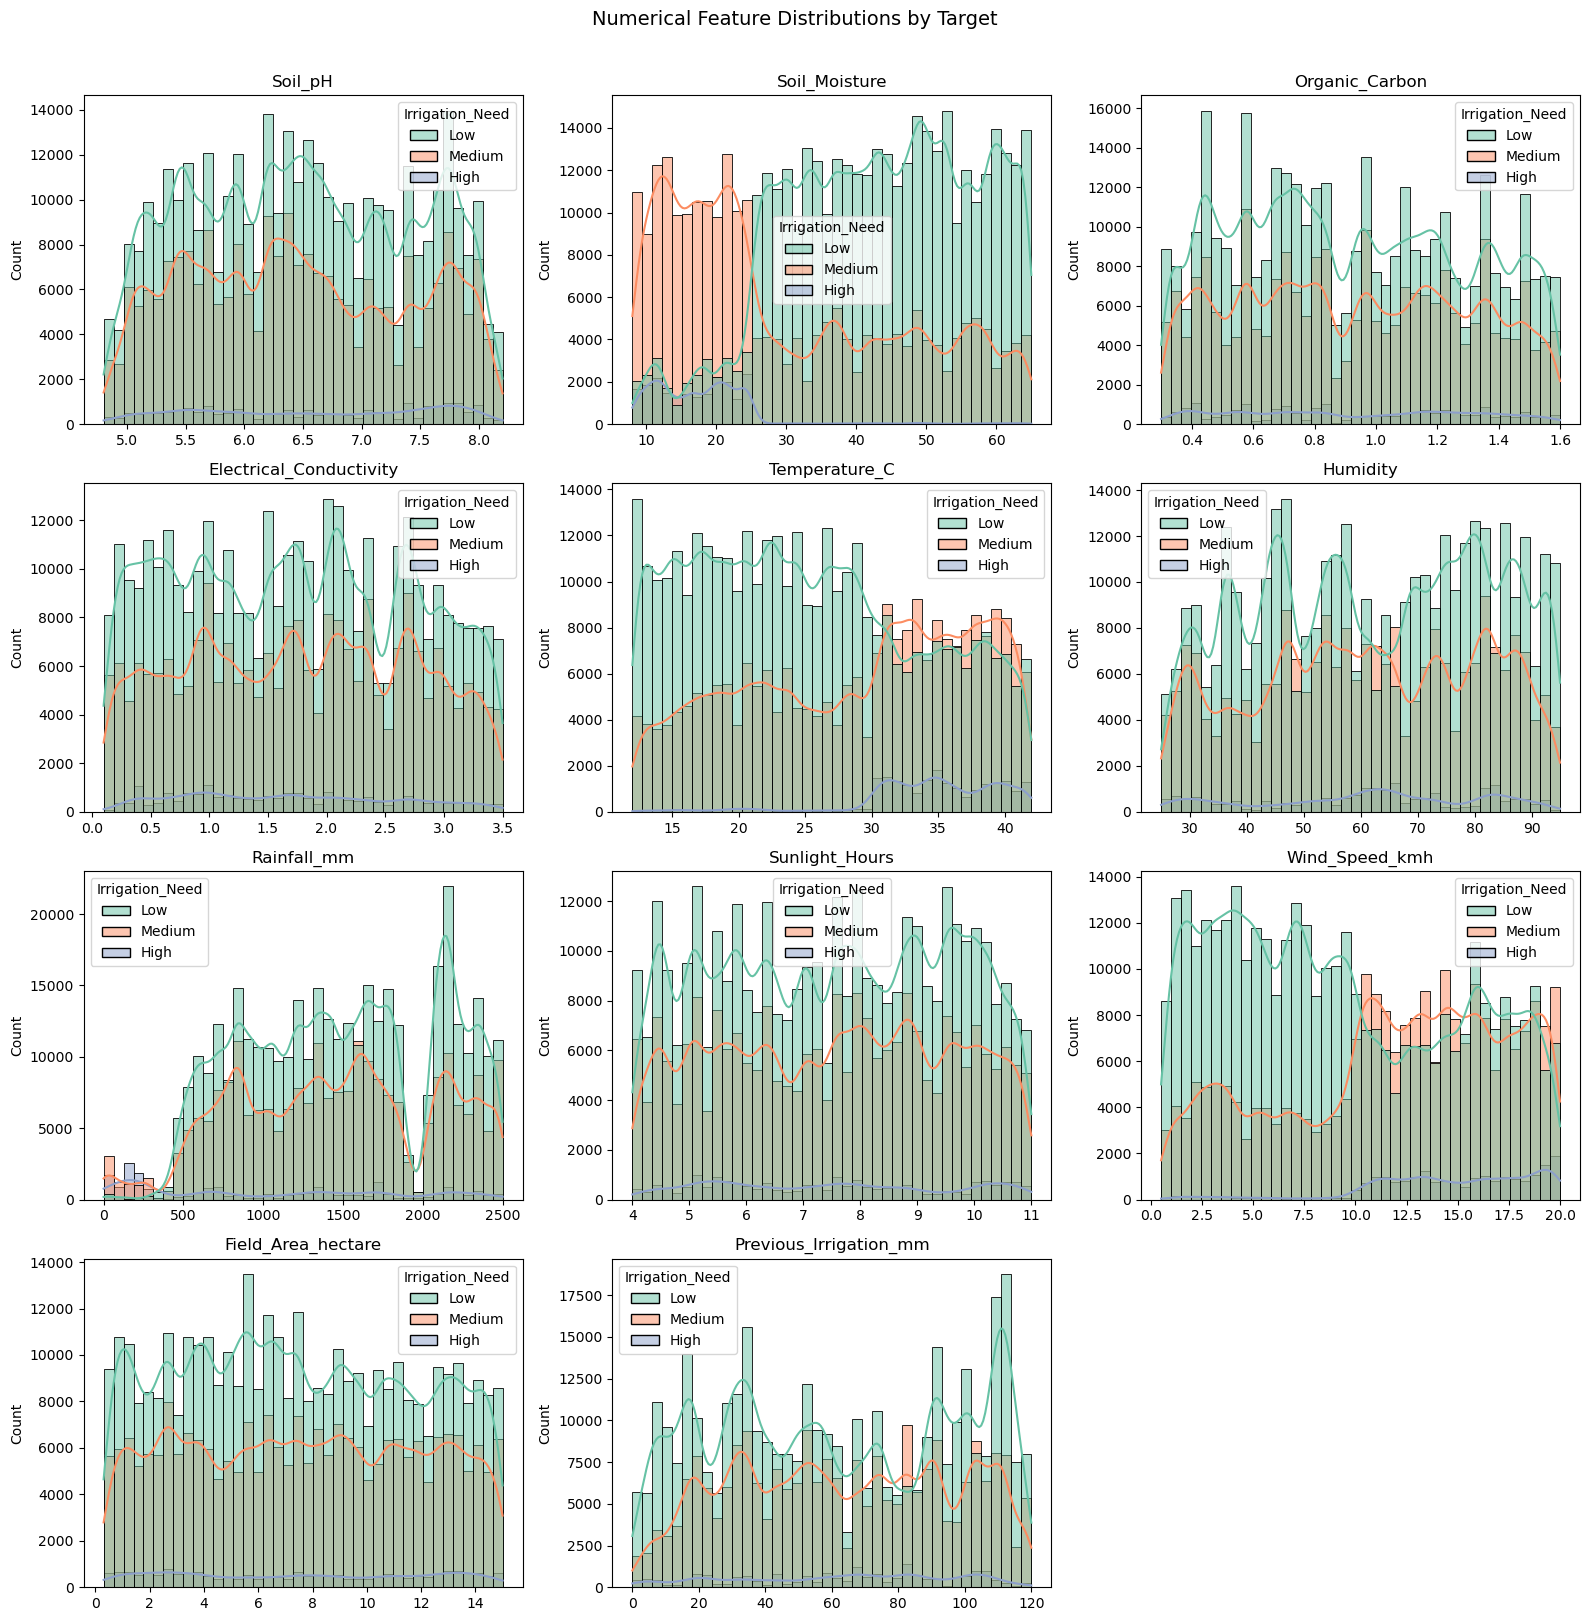

In [5]:
# Numerical Feature Distribution
NUM_COLS = [
    'Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity',
    'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours',
    'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm'
]

train_pd = train_df.to_pandas()

n_cols = 3
n_rows = (len(NUM_COLS) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(NUM_COLS):
    sns.histplot(
        data=train_pd, x=col, hue=TARGET,
        kde=True, bins=40, ax=axes[i], palette='Set2'
    )
    axes[i].set_title(col)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Feature Distributions by Target', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


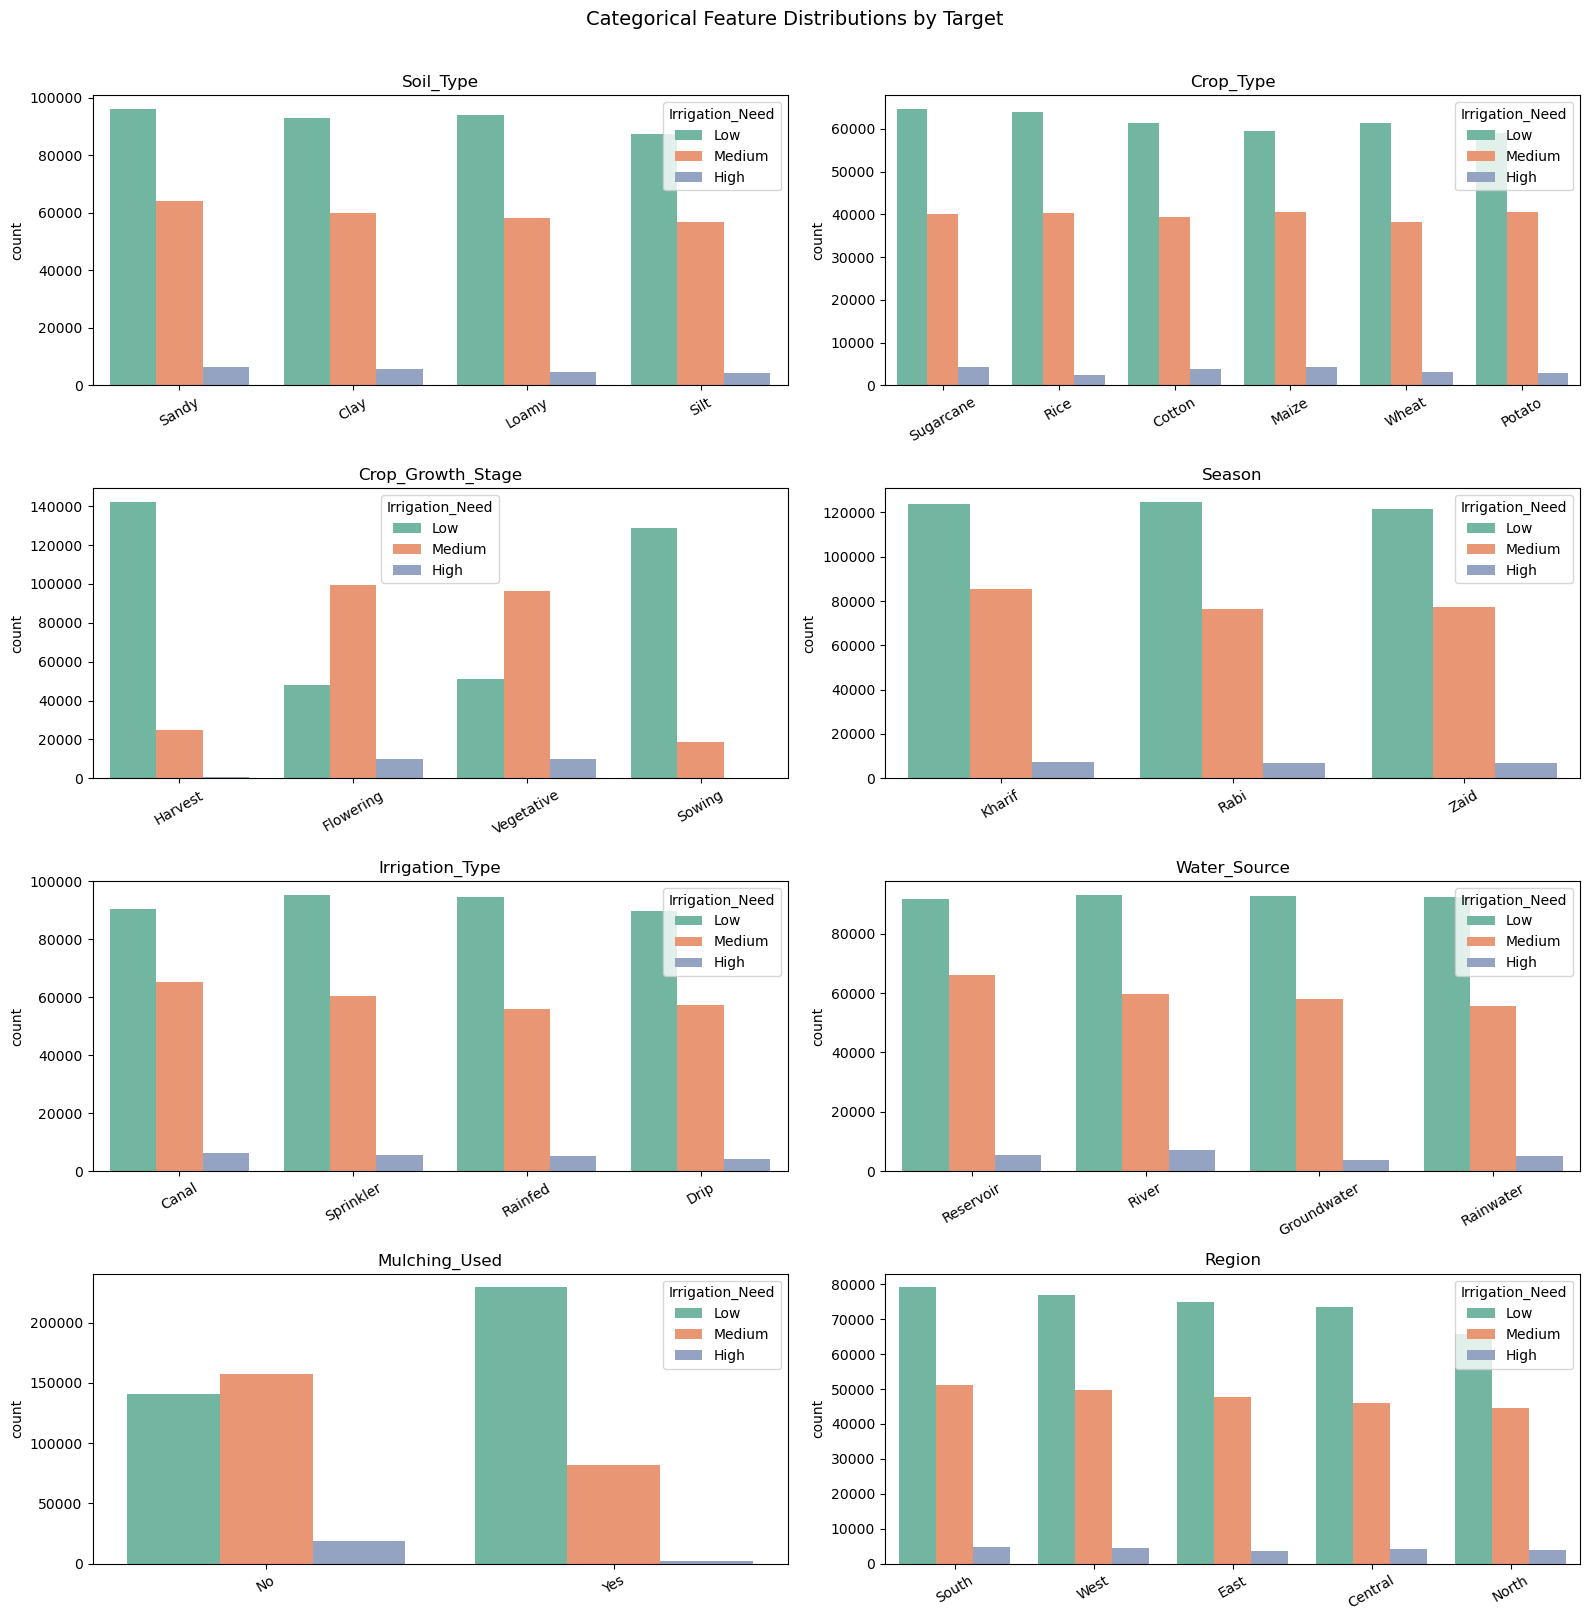

In [6]:
# Categorical Feature Distribution
CAT_COLS = [
    'Soil_Type', 'Crop_Type', 'Crop_Growth_Stage',
    'Season', 'Irrigation_Type', 'Water_Source',
    'Mulching_Used', 'Region'
]

n_cols = 2
n_rows = (len(CAT_COLS) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(CAT_COLS):
    order = train_pd[col].value_counts().index.tolist()
    sns.countplot(
        data=train_pd, x=col, hue=TARGET,
        order=order, palette='Set2', ax=axes[i]
    )
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical Feature Distributions by Target', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

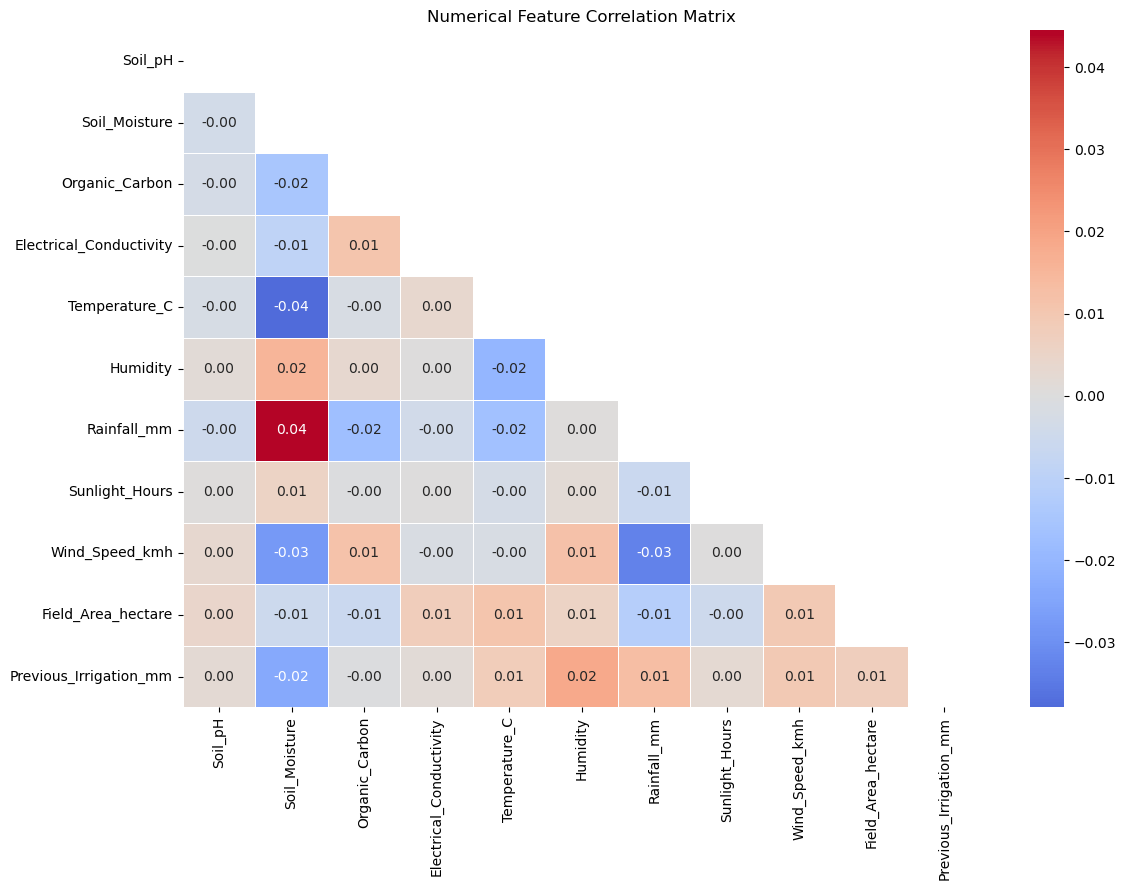

In [7]:
# Correlation Matrix
corr = train_df.select(NUM_COLS).to_pandas().corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.5, ax=ax
)
ax.set_title('Numerical Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# Feature Engineering

In [8]:
NEW_COLS = [
    'heat_dryness_index', 'moisture_deficit',
    'rainfall_per_hectare', 'prev_irrigation_per_hectare', 'ph_deviation',
    'water_balance', 'vpd_proxy', 'moisture_x_rainfall',
    'sunlight_x_temp', 'ph_is_acidic', 'ph_is_alkaline',
    'area_log', 'rainfall_moisture_ratio', 'total_water_input',
    'temp_x_sunlight_humidity'
]

COMBO_COLS = ['region_crop', 'season_stage', 'crop_stage', 'soil_crop']

def add_features(df):
    area_safe = pl.col('Field_Area_hectare').clip(0.1, None)
    return df.with_columns([
        (pl.col('Temperature_C') * (100 - pl.col('Humidity'))).alias('heat_dryness_index'),
        (pl.col('Soil_Moisture') - pl.col('Rainfall_mm') / 100).alias('moisture_deficit'),
        (pl.col('Rainfall_mm') / area_safe).alias('rainfall_per_hectare'),
        (pl.col('Previous_Irrigation_mm') / area_safe).alias('prev_irrigation_per_hectare'),
        (pl.col('Soil_pH') - 6.5).abs().alias('ph_deviation'),
        (pl.col('Rainfall_mm') + pl.col('Previous_Irrigation_mm') - pl.col('Temperature_C')).alias('water_balance'),
        (pl.col('Temperature_C') / (pl.col('Humidity') + 1)).alias('vpd_proxy'),
        (pl.col('Soil_Moisture') * pl.col('Rainfall_mm')).alias('moisture_x_rainfall'),
        (pl.col('Sunlight_Hours') * pl.col('Temperature_C')).alias('sunlight_x_temp'),
        (pl.col('Soil_pH') < 6.0).cast(pl.Int8).alias('ph_is_acidic'),
        (pl.col('Soil_pH') > 7.5).cast(pl.Int8).alias('ph_is_alkaline'),
        area_safe.log().alias('area_log'),
        (pl.col('Rainfall_mm') / (pl.col('Soil_Moisture') + 1)).alias('rainfall_moisture_ratio'),
        (pl.col('Rainfall_mm') + pl.col('Previous_Irrigation_mm')).alias('total_water_input'),
        (pl.col('Temperature_C') * pl.col('Sunlight_Hours') / (pl.col('Humidity') + 1)).alias('temp_x_sunlight_humidity'),
    ])

def add_combo_features(df):
    return df.with_columns([
        (pl.col('Region') + '_' + pl.col('Crop_Type')).alias('region_crop'),
        (pl.col('Season') + '_' + pl.col('Crop_Growth_Stage')).alias('season_stage'),
        (pl.col('Crop_Type') + '_' + pl.col('Crop_Growth_Stage')).alias('crop_stage'),
        (pl.col('Soil_Type') + '_' + pl.col('Crop_Type')).alias('soil_crop'),
    ])

train_df = add_combo_features(add_features(train_df))
test_df  = add_combo_features(add_features(test_df))

print(f'Added {len(NEW_COLS)} derived + {len(COMBO_COLS)} combo features')

Added 15 derived + 4 combo features


In [9]:
def add_group_stats(train_pl, test_pl):
    train_pd = train_pl.to_pandas()
    test_pd  = test_pl.to_pandas()

    groups = [
        ('Crop_Type',  ['Soil_Moisture', 'Previous_Irrigation_mm', 'Rainfall_mm', 'Temperature_C']),
        ('Region',     ['Rainfall_mm', 'Temperature_C', 'Humidity', 'Soil_Moisture']),
        ('Soil_Type',  ['Soil_pH', 'Organic_Carbon', 'Electrical_Conductivity']),
        ('Season',     ['Rainfall_mm', 'Temperature_C', 'Humidity']),
        ('Crop_Growth_Stage', ['Soil_Moisture', 'Rainfall_mm']),
    ]

    new_cols = []
    for grp_col, num_cols in groups:
        for nc in num_cols:
            agg = train_pd.groupby(grp_col)[nc].agg(['mean', 'std']).reset_index()
            mean_name = f'{grp_col}_{nc}_mean'
            std_name  = f'{grp_col}_{nc}_std'
            diff_name = f'{nc}_diff_{grp_col}'
            agg.columns = [grp_col, mean_name, std_name]

            train_pd = train_pd.merge(agg, on=grp_col, how='left')
            test_pd  = test_pd.merge(agg, on=grp_col, how='left')

            train_pd[diff_name] = train_pd[nc] - train_pd[mean_name]
            test_pd[diff_name]  = test_pd[nc]  - test_pd[mean_name]

            new_cols.extend([mean_name, std_name, diff_name])

    return pl.from_pandas(train_pd), pl.from_pandas(test_pd), new_cols

train_df, test_df, GROUP_COLS = add_group_stats(train_df, test_df)
print(f'Added {len(GROUP_COLS)} group aggregation features')

Added 48 group aggregation features


In [10]:
def target_encode_per_class_cv(train_pd, test_pd, cat_cols, target_col,
                                n_classes=3, n_splits=5, random_state=42, smoothing=10):
    """Per-class out-of-fold target encoding. Creates <col>_te_c{k} for each class k.
    Uses smoothed mean: (count*mean + smoothing*global) / (count + smoothing).
    Does NOT overwrite the original categorical column.
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    new_cols = []
    for col in cat_cols:
        for c in range(n_classes):
            train_pd[f'{col}_te_c{c}'] = 0.0
            new_cols.append(f'{col}_te_c{c}')

        test_accum = np.zeros((len(test_pd), n_classes))

        for tr_idx, val_idx in skf.split(train_pd, train_pd[target_col]):
            tr = train_pd.iloc[tr_idx]
            for c in range(n_classes):
                is_c = (tr[target_col] == c).astype(int)
                global_p = is_c.mean()
                stats = tr.assign(_is=is_c).groupby(col)['_is'].agg(['mean', 'count'])
                smoothed = (stats['count'] * stats['mean'] + smoothing * global_p) / (stats['count'] + smoothing)

                train_pd.loc[train_pd.index[val_idx], f'{col}_te_c{c}'] = (
                    train_pd.iloc[val_idx][col].map(smoothed).fillna(global_p).values
                )
                test_accum[:, c] += test_pd[col].map(smoothed).fillna(global_p).values

        for c in range(n_classes):
            test_pd[f'{col}_te_c{c}'] = test_accum[:, c] / n_splits

    return train_pd, test_pd, new_cols

In [11]:
CAT_COLS = [
    'Soil_Type', 'Crop_Type', 'Crop_Growth_Stage',
    'Season', 'Irrigation_Type', 'Water_Source',
    'Mulching_Used', 'Region'
]

NUM_COLS = [
    'Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity',
    'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours',
    'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm'
]

ALL_CAT_COLS = CAT_COLS + COMBO_COLS

# Move to pandas once — encoding + TE is cleaner there
train_pd = train_df.to_pandas()
test_pd  = test_df.to_pandas()

# Ordinal target: Low < Medium < High
ORDER_MAP = {'Low': 0, 'Medium': 1, 'High': 2}
CLASSES   = ['Low', 'Medium', 'High']
N_CLASSES = len(CLASSES)
train_pd[TARGET] = train_pd[TARGET].map(ORDER_MAP).astype(int)

# Label encode all categoricals (original + combos). Keep encoders for reference.
label_encoders = {}
for col in ALL_CAT_COLS:
    le = LabelEncoder()
    combined = pd.concat([train_pd[col].astype(str), test_pd[col].astype(str)])
    le.fit(combined)
    train_pd[col] = le.transform(train_pd[col].astype(str))
    test_pd[col]  = le.transform(test_pd[col].astype(str))
    label_encoders[col] = le

# Per-class target encoding — new columns, originals untouched
train_pd, test_pd, TE_COLS = target_encode_per_class_cv(
    train_pd, test_pd, ALL_CAT_COLS, TARGET,
    n_classes=N_CLASSES, n_splits=5, random_state=42, smoothing=20
)

print(f'Classes (ordinal): {CLASSES}')
print(f'Label-encoded cats: {len(ALL_CAT_COLS)} | TE cols: {len(TE_COLS)}')

Classes (ordinal): ['Low', 'Medium', 'High']
Label-encoded cats: 12 | TE cols: 36


In [12]:
FEATURES = NUM_COLS + ALL_CAT_COLS + NEW_COLS + GROUP_COLS + TE_COLS

X      = train_pd[FEATURES].to_numpy()
y      = train_pd[TARGET].to_numpy()
X_test = test_pd[FEATURES].to_numpy()

# categorical indices (for LGB/CatBoost native handling)
CAT_IDX = [FEATURES.index(c) for c in ALL_CAT_COLS]

print(f'X shape      : {X.shape}')
print(f'y shape      : {y.shape}')
print(f'X_test shape : {X_test.shape}')
print(f'# features   : {len(FEATURES)} (num={len(NUM_COLS)}, cat={len(ALL_CAT_COLS)}, '
      f'derived={len(NEW_COLS)}, group={len(GROUP_COLS)}, te={len(TE_COLS)})')

X shape      : (630000, 122)
y shape      : (630000,)
X_test shape : (270000, 122)
# features   : 122 (num=11, cat=12, derived=15, group=48, te=36)


# Model

In [ ]:
N_SPLITS = 5
LGB_SEED = 42
XGB_SEED = 42

oof_lgb  = np.zeros((len(X), N_CLASSES))
test_lgb = np.zeros((len(X_test), N_CLASSES))

oof_xgb  = np.zeros((len(X), N_CLASSES))
test_xgb = np.zeros((len(X_test), N_CLASSES))

# ---------- LightGBM (stronger regularization to close OOF-LB gap) ----------
lgb_params = {
    'objective': 'multiclass',
    'num_class': N_CLASSES,
    'metric': 'multi_logloss',
    'learning_rate': 0.03,
    'num_leaves': 31,
    'max_depth': 6,
    'min_child_samples': 500,
    'feature_fraction': 0.6,
    'bagging_fraction': 0.7,
    'bagging_freq': 1,
    'lambda_l1': 0.5,
    'lambda_l2': 3.0,
    'min_gain_to_split': 0.02,
    'seed': LGB_SEED,
    'verbose': -1,
}

lgb_last_model = None
print('=== LightGBM ===')
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=LGB_SEED)
for fold, (tr, va) in enumerate(skf.split(X, y)):
    dtr = lgb.Dataset(X[tr], label=y[tr], categorical_feature=CAT_IDX)
    dva = lgb.Dataset(X[va], label=y[va], reference=dtr, categorical_feature=CAT_IDX)
    model = lgb.train(
        lgb_params, dtr, num_boost_round=5000,
        valid_sets=[dva],
        callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(0)]
    )
    oof_lgb[va] = model.predict(X[va])
    test_lgb   += model.predict(X_test) / N_SPLITS
    lgb_last_model = model
    print(f'  fold={fold+1} best_iter={model.best_iteration}')

lgb_acc = accuracy_score(y, oof_lgb.argmax(axis=1))
print(f'LGB OOF Accuracy: {lgb_acc:.5f}')

# ---------- XGBoost (stronger regularization) ----------
xgb_params = {
    'objective': 'multi:softprob',
    'num_class': N_CLASSES,
    'eval_metric': 'mlogloss',
    'learning_rate': 0.03,
    'max_depth': 5,
    'min_child_weight': 20,
    'subsample': 0.7,
    'colsample_bytree': 0.6,
    'reg_alpha': 0.5,
    'reg_lambda': 3.0,
    'gamma': 1.0,
    'tree_method': 'hist',
    'seed': XGB_SEED,
    'verbosity': 0,
}

print('\n=== XGBoost ===')
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=XGB_SEED)
for fold, (tr, va) in enumerate(skf.split(X, y)):
    dtr = xgb.DMatrix(X[tr], label=y[tr])
    dva = xgb.DMatrix(X[va], label=y[va])
    dte = xgb.DMatrix(X_test)
    model = xgb.train(
        xgb_params, dtr, num_boost_round=5000,
        evals=[(dva, 'val')],
        early_stopping_rounds=100, verbose_eval=0
    )
    oof_xgb[va] = model.predict(dva)
    test_xgb   += model.predict(dte) / N_SPLITS
    print(f'  fold={fold+1} best_iter={model.best_iteration}')

xgb_acc = accuracy_score(y, oof_xgb.argmax(axis=1))
print(f'XGB OOF Accuracy: {xgb_acc:.5f}')

# ---------- Feature importance (last LGB fold) ----------
fi = pd.DataFrame({
    'feature': FEATURES,
    'gain': lgb_last_model.feature_importance(importance_type='gain'),
    'split': lgb_last_model.feature_importance(importance_type='split'),
}).sort_values('gain', ascending=False).reset_index(drop=True)

print('\nTop 20 features by gain:')
print(fi.head(20).to_string(index=False))
print('\nBottom 15 features by gain (candidates to drop):')
print(fi.tail(15).to_string(index=False))

In [14]:
oof_list  = [oof_lgb,  oof_xgb]
test_list = [test_lgb, test_xgb]
names     = ['LGB', 'XGB']

def blend(weights, probs_list):
    w = np.clip(np.asarray(weights, dtype=float), 0, None)
    if w.sum() == 0:
        w = np.ones_like(w)
    w = w / w.sum()
    return sum(wi * p for wi, p in zip(w, probs_list))

def neg_logloss(weights, probs_list, y_true):
    blend_p = blend(weights, probs_list)
    return log_loss(y_true, np.clip(blend_p, 1e-15, 1 - 1e-15))

# Find weights that minimize OOF log-loss
res = minimize(
    neg_logloss,
    x0=np.ones(len(oof_list)) / len(oof_list),
    args=(oof_list, y),
    method='Nelder-Mead',
    options={'xatol': 1e-4, 'fatol': 1e-6, 'maxiter': 500}
)
w_opt = np.clip(res.x, 0, None)
w_opt = w_opt / w_opt.sum()

print('Optimal weights:')
for n, w in zip(names, w_opt):
    print(f'  {n}: {w:.3f}')

oof_blend  = blend(w_opt, oof_list)
test_preds = blend(w_opt, test_list)

blend_acc = accuracy_score(y, oof_blend.argmax(axis=1))
print(f'\nBlend OOF Accuracy: {blend_acc:.5f}')
print(f'LGB:   {accuracy_score(y, oof_lgb.argmax(axis=1)):.5f}')
print(f'XGB:   {accuracy_score(y, oof_xgb.argmax(axis=1)):.5f}')
print()
print(classification_report(y, oof_blend.argmax(axis=1), target_names=CLASSES))

Optimal weights:
  LGB: 0.368
  XGB: 0.632

Blend OOF Accuracy: 0.98511
LGB:   0.98487
XGB:   0.98492

              precision    recall  f1-score   support

         Low       0.99      1.00      0.99    369917
      Medium       0.99      0.98      0.98    239074
        High       0.97      0.92      0.94     21009

    accuracy                           0.99    630000
   macro avg       0.98      0.96      0.97    630000
weighted avg       0.99      0.99      0.99    630000



# Pseudo-Labeling

In [ ]:
# Pseudo-labeling — disabled by default (hurt LB in prior experiment).
# Set RUN_PL = True to try again, possibly with a tighter threshold.
RUN_PL = False
PL_THRESHOLD = 0.99

if RUN_PL:
    max_probs = test_preds.max(axis=1)
    pseudo_labels_arr = test_preds.argmax(axis=1)

    print('Test confidence distribution:')
    for thr in [0.80, 0.90, 0.95, 0.99]:
        n = (max_probs > thr).sum()
        print(f'  > {thr:.2f} : {n:>7} rows ({n / len(max_probs):.1%})')

    mask = max_probs > PL_THRESHOLD
    print(f'\nUsing threshold {PL_THRESHOLD} -> {mask.sum()} pseudo-labeled rows')

    X_pseudo = X_test[mask]
    y_pseudo = pseudo_labels_arr[mask]

    X_full = np.vstack([X, X_pseudo])
    y_full = np.concatenate([y, y_pseudo])
    pseudo_idx = np.arange(len(X), len(X) + len(X_pseudo))

    oof_lgb_pl  = np.zeros((len(X), N_CLASSES))
    test_lgb_pl = np.zeros((len(X_test), N_CLASSES))
    oof_xgb_pl  = np.zeros((len(X), N_CLASSES))
    test_xgb_pl = np.zeros((len(X_test), N_CLASSES))

    print('\n=== LightGBM (PL) ===')
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=LGB_SEED)
    for fold, (tr, va) in enumerate(skf.split(X, y)):
        tr_aug = np.concatenate([tr, pseudo_idx])
        dtr = lgb.Dataset(X_full[tr_aug], label=y_full[tr_aug], categorical_feature=CAT_IDX)
        dva = lgb.Dataset(X[va], label=y[va], reference=dtr, categorical_feature=CAT_IDX)
        model = lgb.train(
            lgb_params, dtr, num_boost_round=5000,
            valid_sets=[dva],
            callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(0)]
        )
        oof_lgb_pl[va] = model.predict(X[va])
        test_lgb_pl  += model.predict(X_test) / N_SPLITS
        print(f'  fold={fold+1} best_iter={model.best_iteration}')
    print(f'LGB+PL OOF: {accuracy_score(y, oof_lgb_pl.argmax(axis=1)):.5f}')

    print('\n=== XGBoost (PL) ===')
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=XGB_SEED)
    for fold, (tr, va) in enumerate(skf.split(X, y)):
        tr_aug = np.concatenate([tr, pseudo_idx])
        dtr = xgb.DMatrix(X_full[tr_aug], label=y_full[tr_aug])
        dva = xgb.DMatrix(X[va], label=y[va])
        dte = xgb.DMatrix(X_test)
        model = xgb.train(
            xgb_params, dtr, num_boost_round=5000,
            evals=[(dva, 'val')],
            early_stopping_rounds=100, verbose_eval=0
        )
        oof_xgb_pl[va] = model.predict(dva)
        test_xgb_pl  += model.predict(dte) / N_SPLITS
        print(f'  fold={fold+1} best_iter={model.best_iteration}')
    print(f'XGB+PL OOF: {accuracy_score(y, oof_xgb_pl.argmax(axis=1)):.5f}')

    oof_list_pl  = [oof_lgb_pl,  oof_xgb_pl]
    test_list_pl = [test_lgb_pl, test_xgb_pl]

    res = minimize(
        neg_logloss, x0=np.ones(len(oof_list_pl)) / len(oof_list_pl),
        args=(oof_list_pl, y), method='Nelder-Mead',
        options={'xatol': 1e-4, 'fatol': 1e-6, 'maxiter': 500}
    )
    w_pl = np.clip(res.x, 0, None); w_pl = w_pl / w_pl.sum()
    oof_blend_pl = blend(w_pl, oof_list_pl)
    test_preds   = blend(w_pl, test_list_pl)

    blend_acc_pl = accuracy_score(y, oof_blend_pl.argmax(axis=1))
    print(f'\nBlend OOF (pre-PL):  {blend_acc:.5f}')
    print(f'Blend OOF (post-PL): {blend_acc_pl:.5f}  (delta {blend_acc_pl - blend_acc:+.5f})')
    print()
    print(classification_report(y, oof_blend_pl.argmax(axis=1), target_names=CLASSES))
else:
    print('Pseudo-labeling skipped (RUN_PL=False). Using pre-PL test_preds.')

In [17]:
pred_labels = [CLASSES[i] for i in test_preds.argmax(axis=1)]

submission = pl.DataFrame({
    'id': test_pd['id'].to_numpy(),
    TARGET: pred_labels,
})

submission.write_csv('../submissions/submission.csv')
print(submission.head())
print('\nPrediction distribution:')
print(pd.Series(pred_labels).value_counts())

shape: (5, 2)
┌────────┬─────────────────┐
│ id     ┆ Irrigation_Need │
│ ---    ┆ ---             │
│ i64    ┆ str             │
╞════════╪═════════════════╡
│ 630000 ┆ Low             │
│ 630001 ┆ Low             │
│ 630002 ┆ Low             │
│ 630003 ┆ Low             │
│ 630004 ┆ Low             │
└────────┴─────────────────┘

Prediction distribution:
Low       159881
Medium    101566
High        8553
Name: count, dtype: int64
